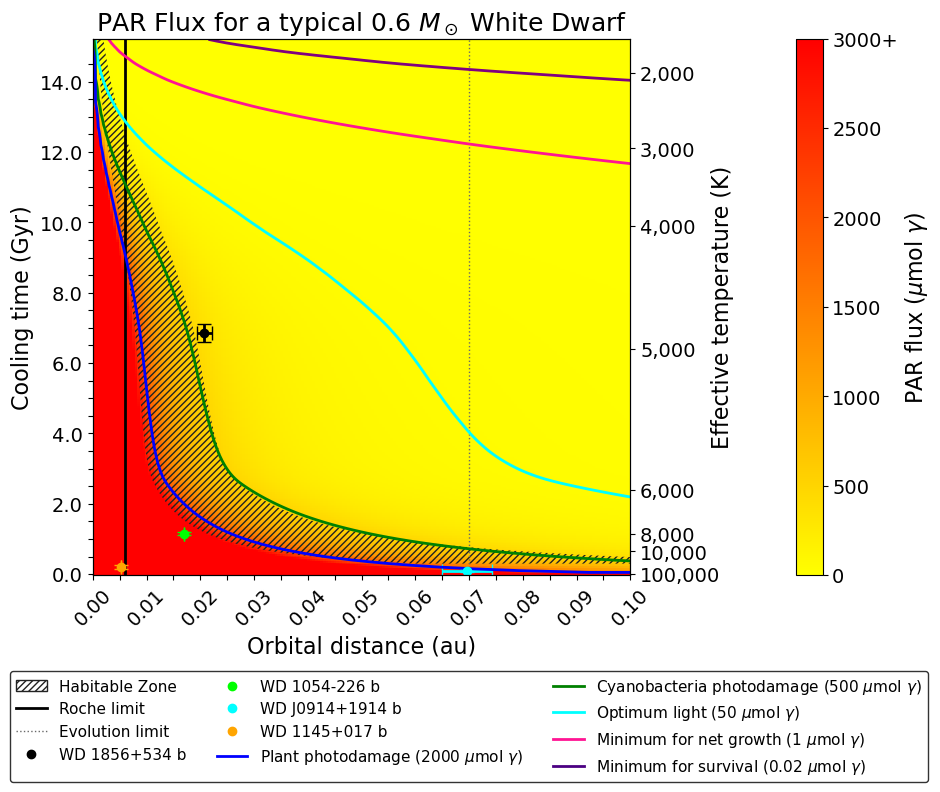

In [19]:
## Using simple model of a photosystem and WD flux to calculate PAR flux and various photosynthetic measures

# 1.1 PAR flux

# Load chosen WD mass cooling curve and pick x evenly spaced temp/age/radius points

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.constants import h, c, Boltzmann as kB

# Load the WD 0.6 Msun data
data = np.loadtxt("WD_060Mo.txt", skiprows=1)
teffs_all, ages_all, radii_all, luminosities_all = data.T  # data.T transposes columns in .txt file into separate arrays in order of appearance 

# Choose x evenly spaced samples
teffs = teffs_all
radii = radii_all
ages = ages_all

# Choose orbital distance range and number of points 

AU = 1.496e11  # AU in meters
orbital_distances = np.arange(0.0001*AU, 0.155*AU, 0.0005*AU)  # in metres! An array of x orbital distances (in AU) is created, to be later used in "for D in orbital_distances::

# Black body Planck Function (spectral radiance [power per unit area per solid angle or 'steradian' per unit wavelength, in a specific direction])

def B_planck(L, T):
    A = (2.0 * h * c ** 2) / (L ** 5)
    exponent = (h * c) / (L * kB * T)
    return A / (np.exp(exponent) - 1.0)


# Generate stellar surface flux density for each extracted Teff

# Key constants 
AU = 1.496e11
l_range = np.arange(200e-9, 1000e-9, 1e-9)  # Wavelengths in meters
l_nm = l_range * 1e9  # Converts wavelength to nm for use in antenna model

def stellar_surface_flux(T): # at each Teff
    B_lambda = np.pi * B_planck(l_range, T)  # Multiply by pi to convert spectral radiance to stellar surface flux density (power per square meter of the star's surface over all directions, per unit wavelength)
    B_nm = B_lambda * 1e-9 # convert # W/m²/m to # W/m²/nm
    return B_nm


# Generate incident fluxes in Wm^-2nm^-1

def incident_flux(B_nm, R, D):
    F_nm = B_nm * ((R / D) ** 2)
    return F_nm

# Make a grid of orbital distances (#N values) and temp/age/radius (#N values) and run through antenna models.

# Helper functions
def compute_PAR_flux(l_nm, F_nm):
    mask = (l_nm >= 400) & (l_nm <= 700)
    return np.trapz(F_nm[mask], l_nm[mask])

# Run through simple antenna model
def uE_PAR_flux(l_nm, F_nm):
    l_m = l_nm * 1e-9  # convert nm → m

    # Convert incident flux in W m^-2 nm^-1 (J s^-1 m^-2 nm^-1) to photon flux (#photons m^-2 s^-1 nm^-1)
    photon_flux = (F_nm * l_m) / (h * c)
    photon_flux_uE = photon_flux / 6.02e17 #convert photon flux (#photons m^-2 s^-1 nm^-1) to uE (umol photons m^-2 s^-1 nm^-1)

    # Compute PAR (400–700 nm)
    mask = (l_nm >= 400) & (l_nm <= 700)
    PAR = np.trapz(photon_flux_uE[mask], l_nm[mask])  # integrating removes nm leaving units of umol photons s^-1 m^-2

    return PAR


# Making the grid of orbital distances (#N values) and temp/age/radius (#N values) and run through antenna models.
results = []  # Make sure to define results as an empty list before the loop
for T, R, A in zip(teffs, radii, ages):  # From Step 1 (note 'T' and 'R' could be any letters, they just refer to each value in the teffs array and radii array made in step 1)
    B_nm = stellar_surface_flux(T)  # From Step 4. Creates stellar surface flux for each Teff now.

    for D in orbital_distances:  # From Step 2 (note 'D' could be any letter, just refers to each value in the orbital_distances array made in step 2)
        F_nm = incident_flux(B_nm, R, D)  # From Step 5. Creates incident flux for each Teff/radius and each orbital distance now.

        PAR_flux = uE_PAR_flux(l_nm, F_nm)

        # Step 7: Store Results
        result = {
            'Teff': T,
            'Radius': R,
            'Age': A,
            'Distance': D,
            'PAR_flux': PAR_flux,
        }
        results.append(result)


# Make heatmaps

df = pd.DataFrame(results)
df['Distance_AU'] = df['Distance'] / AU  # Convert Distance from meters to AU

# Create pivot table for heatmap data
heat_data = df.pivot_table(index='Age', columns='Distance_AU', values='PAR_flux')
heat_data = heat_data.sort_index(ascending=False)

cmap = plt.get_cmap('autumn_r')

import matplotlib.colors as mcolors

# Define normalization with center at 0.017
norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=1500, vmax=3000)
# Then use this norm in imshow
fig, ax = plt.subplots(figsize=(10, 8.5)) 
im = ax.imshow(
    heat_data.values, 
    #subset.values,
    aspect='auto', 
    interpolation='nearest',  # or 'bicubic', 'nearest', etc.
    cmap=cmap,
    norm=norm
)

# Create and customize colorbar
cbar = plt.colorbar(im, ax=ax, pad=0.2)
cbar.set_ticks([0, 500, 1000, 1500, 2000, 2500, 3000])
cbar.set_ticklabels(['0', '500', '1000', '1500', '2000', '2500', '3000+'])
cbar.set_label(r'PAR flux ($\mu$mol $\gamma$)', fontsize=16)
cbar.ax.tick_params(labelsize=14) # cbar tick size

# Get age values and indices
ages = heat_data.index.values
tick_values = np.arange(0, 15, 0.5)  # Ticks every 0.5 Gyr
tick_positions = [np.argmin(np.abs(ages - val)) for val in tick_values]
# Set labels only for every 2 Gyr, empty for others
tick_labels = [f"{val:.1f}" if val % 2 == 0 else "" for val in tick_values]
# Apply custom ticks and labels
ax.set_yticks(ticks=tick_positions, labels=tick_labels)

orbital_distances = heat_data.columns.values 

# Start with 0.00 manually, then generate the rest
x_tick_values = np.concatenate([[0.00], np.linspace(0.005, 0.10, 20)])
x_tick_positions = [np.argmin(np.abs(orbital_distances - val)) for val in x_tick_values]
x_tick_labels = [f"{val:.2f}" if round(val * 1000) % 10 == 0 or val == 0.00 else "" for val in x_tick_values]
cbar.ax.tick_params(labelsize=14)

ax.set_xticks(ticks=x_tick_positions)
ax.set_xticklabels(x_tick_labels, rotation=45)

idx_010 = np.searchsorted(heat_data.columns.values, 0.10)
ax.set_xlim(0, idx_010)


ax.set_xlabel('Orbital distance (au)', fontsize=16)
ax.set_ylabel('Cooling time (Gyr)', fontsize=16)
ax.set_title(r'PAR Flux for a typical 0.6 $M_\odot$ White Dwarf', fontsize=18)

ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())

# Get all available Teff values from your data
available_teffs = np.array(sorted(set(teffs_all), reverse=True))  # descending order

# Desired Teff ticks (labels)
desired_teff_ticks = np.array([100000, 10000, 8000, 6000, 5000, 4000, 3000, 2000])

# Get all unique Teff–Age pairs
unique_teff_age = sorted(set(zip(teffs_all, ages_all)), key=lambda x: x[1], reverse=True)  # sort by age descending

# Create arrays
sorted_teffs, sorted_ages = zip(*unique_teff_age)
sorted_teffs = np.array(sorted_teffs)
sorted_ages = np.array(sorted_ages)

# Find closest available Teff to each desired tick
closest_teff_values = [min(sorted_teffs, key=lambda x: abs(x - val)) for val in desired_teff_ticks]

# Get index (row position) in heatmap based on Age that corresponds to each Teff
tick_positions = [np.argmin(np.abs(heat_data.index.values - sorted_ages[np.where(sorted_teffs == teff)[0][0]])) for teff in closest_teff_values]

from matplotlib.ticker import FixedLocator, FixedFormatter

# Explicitly set locator and formatter to avoid default ticks
ax2.yaxis.set_major_locator(FixedLocator(tick_positions))
ax2.yaxis.set_major_formatter(FixedFormatter([f"{val:,}" for val in desired_teff_ticks]))

ax2.set_ylabel('Effective temperature (K)', fontsize=16)
ax2.yaxis.set_label_position("right")
ax2.yaxis.set_label_coords(1.15, 0.5)  # (x, y) relative to axes

# Make axis tick labels bigger
ax.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='y', labelsize=14)


# ADDING ROCHE LIMIT
Pearth = 5.5  # g/cm^3 (Earth-like planetary density)
rho_earth = 5.5  # g/cm^3 (density of Earth)
scaling_factor = 7.27e-3  # Scaling factor for Roche limit in AU
#Msolar = 1.989e30  # Solar mass in kg

# Calculate the Roche limit in AU
Roche_AU = scaling_factor * (Pearth / rho_earth)**(-1/3) * (0.6)**(1/3)
#print(Roche_AU)

# Find insertion position in orbital_distances to keep array sorted
pos = np.searchsorted(orbital_distances, Roche_AU)
#print(pos) # For example, pos might be 1 (since 0.006 is between 0.005 (index 0) and 0.01 (index 1))

# Lower and upper AU bounds for pixels around target_au
lower_au = orbital_distances[pos - 1]
upper_au = orbital_distances[pos]

# Fraction along between those two pixels:
fraction = (Roche_AU - lower_au) / (upper_au - lower_au)

# Corresponding x position for axvline:
x_pos = (pos - 1) + fraction

ax.axvline(x=x_pos, color='black', linestyle='-', linewidth=2, alpha=1, label='Roche limit')


# ADDING HZ 

A = 0.3
Tplanet_inner = 270.0
Tplanet_outer = 175.0

D_hz_inner = (radii / 2) * (teffs**2 * np.sqrt(1 - A)) / (Tplanet_inner**2)
D_hz_outer = (radii / 2) * (teffs**2 * np.sqrt(1 - A)) / (Tplanet_outer**2)

D_hz_inner_AU = D_hz_inner / AU
D_hz_outer_AU = D_hz_outer / AU

def au_to_xpos(au_vals, orbital_distances):
    scalar_input = np.isscalar(au_vals)
    au_vals = np.atleast_1d(au_vals)

    xpos = []
    for au in au_vals:
        if au < orbital_distances[0] or au > orbital_distances[-1]:
            xpos.append(np.nan)
            continue

        pos = np.searchsorted(orbital_distances, au)

        if pos == 0:
            xpos.append(0)
            continue

        lower_au = orbital_distances[pos - 1]
        upper_au = orbital_distances[pos]

        fraction = (au - lower_au) / (upper_au - lower_au)
        xpos.append((pos - 1) + fraction)

    xpos = np.array(xpos)

    return xpos[0] if scalar_input else xpos

# Apply au_to_xpos to the HZ boundaries
hz_inner_x = au_to_xpos(D_hz_inner_AU, orbital_distances)
hz_outer_x = au_to_xpos(D_hz_outer_AU, orbital_distances)

#heatmap_ypos = np.array([np.argmin(np.abs(heat_data.index.values - a)) for a in ages])
# Length of heatmap rows
n_rows = len(heat_data.index)

# Get positions from the reversed index to match heatmap orientation
heatmap_ypos = np.array([np.argmin(np.abs(heat_data.index.values - a)) for a in ages])
heatmap_ypos = n_rows - 1 - heatmap_ypos

#Fill between HZ hatching
ax.fill_betweenx(heatmap_ypos, hz_inner_x, hz_outer_x,facecolor='none', edgecolor='#222222', hatch='/////',linewidth=0.0, label='Habitable Zone')

# ADD CROSS ERROR BAR (horizontal and vertical)

x_center_au = 0.02085
x_err_au = 0.0014

# New age-based values in Gyr
y_center_age = 6.850  # midpoint (this is the closest age to 4920 K)
y_err_age = 0.25      # this is the closest age range for the +-50 K around 4920 K

# Convert AU to heatmap x-axis (column) position as before
def au_to_xpos(au_val, orbital_distances):
    pos = np.searchsorted(orbital_distances, au_val)
    if pos == 0:
        return 0
    lower_au = orbital_distances[pos - 1]
    upper_au = orbital_distances[pos]
    fraction = (au_val - lower_au) / (upper_au - lower_au)
    return (pos - 1) + fraction

x_pos_center = au_to_xpos(x_center_au, orbital_distances)
x_pos_err = au_to_xpos(x_center_au + x_err_au, orbital_distances) - x_pos_center

# Convert Age to heatmap y-axis (row) index position
age_values = heat_data.index.values  # assumed sorted descending (e.g., 13.0 -> 0.1)

# Get the row index that best matches the age
y_pos_center = np.argmin(np.abs(age_values - y_center_age))

# Get vertical uncertainty in row index units
y_upper = y_center_age + y_err_age
y_lower = y_center_age - y_err_age

y_pos_upper = np.argmin(np.abs(age_values - y_upper))
y_pos_lower = np.argmin(np.abs(age_values - y_lower))
y_pos_err = abs(y_pos_upper - y_pos_lower) / 2

# Plot the errorbar using row/column index space
ax.errorbar(
    x=x_pos_center,
    y=y_pos_center,
    xerr=x_pos_err,
    yerr=y_pos_err,
    fmt='o',
    color='black',
    elinewidth=2,
    capsize=5,
    label='WD 1856+534 b'
)

# ===============================
# Planet 2: WD 1054-226 b
# ===============================

x_center_au_2 = 0.017     # orbital distance in AU
x_err_au_2    = 0.000

y_center_age_2 = 1.15      # cooling age in Gyr
y_err_age_2    = 0.05

# X-position
x_pos_center_2 = au_to_xpos(x_center_au_2, orbital_distances)
x_pos_err_2 = au_to_xpos(x_center_au_2 + x_err_au_2, orbital_distances) - x_pos_center_2

# Y-position
y_pos_center_2 = np.argmin(np.abs(age_values - y_center_age_2))

y_upper_2 = y_center_age_2 + y_err_age_2
y_lower_2 = y_center_age_2 - y_err_age_2

y_pos_upper_2 = np.argmin(np.abs(age_values - y_upper_2))
y_pos_lower_2 = np.argmin(np.abs(age_values - y_lower_2))
y_pos_err_2 = abs(y_pos_upper_2 - y_pos_lower_2) / 2

# Plot second planet
ax.errorbar(
    x=x_pos_center_2,
    y=y_pos_center_2,
    xerr=x_pos_err_2,
    yerr=y_pos_err_2,
    fmt='o',
    color='lime',
    elinewidth=2,
    capsize=5,
    label='WD 1054-226 b'
)

# ===============================
# Planet 3: WD J0914+1914 b
# ===============================

x_center_au_3 = 0.06975     # orbital distance in AU
x_err_au_3    = 0.0047

y_center_age_3 = 0.1      # cooling age in Gyr
y_err_age_3    = 0.05

# X-position
x_pos_center_3 = au_to_xpos(x_center_au_3, orbital_distances)
x_pos_err_3 = au_to_xpos(x_center_au_3 + x_err_au_3, orbital_distances) - x_pos_center_3

# Y-position
y_pos_center_3 = np.argmin(np.abs(age_values - y_center_age_3))

y_upper_3 = y_center_age_3 + y_err_age_3
y_lower_3 = y_center_age_3 - y_err_age_3

y_pos_upper_3 = np.argmin(np.abs(age_values - y_upper_3))
y_pos_lower_3 = np.argmin(np.abs(age_values - y_lower_3))
y_pos_err_3 = abs(y_pos_upper_3 - y_pos_lower_3) / 2

# Plot third planet
ax.errorbar(
    x=x_pos_center_3,
    y=y_pos_center_3,
    xerr=x_pos_err_3,
    yerr=y_pos_err_3,
    fmt='o',
    color='cyan',
    elinewidth=2,
    capsize=5,
    label='WD J0914+1914 b'
)

# ===============================
# Planet 4: WD 1145+017 b
# ===============================

x_center_au_4 = 0.0054     # orbital distance in AU
x_err_au_4    = 0.0000

y_center_age_4 = 0.2      # cooling age in Gyr
y_err_age_4    = 0.05

# X-position
x_pos_center_4 = au_to_xpos(x_center_au_4, orbital_distances)
x_pos_err_4 = au_to_xpos(x_center_au_4 + x_err_au_4, orbital_distances) - x_pos_center_4

# Y-position
y_pos_center_4 = np.argmin(np.abs(age_values - y_center_age_4))

y_upper_4 = y_center_age_4 + y_err_age_4
y_lower_4 = y_center_age_4 - y_err_age_4

y_pos_upper_4 = np.argmin(np.abs(age_values - y_upper_4))
y_pos_lower_4 = np.argmin(np.abs(age_values - y_lower_4))
y_pos_err_4 = abs(y_pos_upper_4 - y_pos_lower_4) / 2

# Plot fourth planet
ax.errorbar(
    x=x_pos_center_4,
    y=y_pos_center_4,
    xerr=x_pos_err_4,
    yerr=y_pos_err_4,
    fmt='o',
    color='orange',
    elinewidth=2,
    capsize=5,
    label='WD 1145+017 b'
)

#Adding evolutionary limit
target_au = 0.070

x_pos_070 = au_to_xpos(target_au, orbital_distances)

ax.axvline(
    x=x_pos_070,
    color='dimgrey',
    linestyle=':',
    linewidth=1.0
)

# Add PAR threshold contours
levels = [0.02, 1, 50, 500, 2000]

colors = [
    'purple',   # 0.02 μE
    'deeppink',   # 1 μE
    'cyan',     # 50 μE
    'green',    # 500 μE
    'blue'      # 2000 μE
]

contours = ax.contour(
    heat_data.values,
    levels=levels,
    colors=colors,
    linewidths=2
)


from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_handles = [
    Patch(facecolor='none', edgecolor='#222222', hatch='/////', label='Habitable Zone'),
    Line2D([0], [0], color='black', lw=2, label='Roche limit'),
    Line2D([0], [0], color='dimgrey', lw=1, linestyle=':', label='Evolution limit'),

    Line2D([0], [0], marker='o', color='black', lw=0, label='WD 1856+534 b'),
    Line2D([0], [0], marker='o', color='lime', lw=0, label='WD 1054-226 b'),
    Line2D([0], [0], marker='o', color='cyan', lw=0, label='WD J0914+1914 b'),
    Line2D([0], [0], marker='o', color='orange', lw=0, label='WD 1145+017 b'),

    Line2D([0], [0], color='blue', lw=2, label='Plant photodamage (2000 $\mu$mol $\gamma$)'),
    Line2D([0], [0], color='green', lw=2, label='Cyanobacteria photodamage (500 $\mu$mol $\gamma$)'),
    Line2D([0], [0], color='cyan', lw=2, label='Optimum light (50 $\mu$mol $\gamma$)'),
    Line2D([0], [0], color='deeppink', lw=2, label='Minimum for net growth (1 $\mu$mol $\gamma$)'),
    Line2D([0], [0], color='indigo', lw=2, label='Minimum for survival (0.02 $\mu$mol $\gamma$)'),
]

ax.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.70, -0.40),
    fontsize=11,
    facecolor='white',
    edgecolor='black',
    ncol=3
)

plt.tight_layout()
plt.show()



In [11]:
# 1.2 PAR SELECTION

# Filter for x Gyr cooling age (closest match)
target_age = 6.85

# Find closest age row
df_age1 = df.iloc[(df['Age'] - target_age).abs().argsort()[:1]]

# Minimum, average, maximum over all distances and ages (unchanged)
par_min = df['PAR_flux'].min()
par_avg = df['PAR_flux'].mean()
par_max = df['PAR_flux'].max()

# PAR flux at x AU and y Gyr
target_distance = 0.02085
df_target = df.copy()
df_target['dist_diff'] = np.abs(df_target['Distance_AU'] - target_distance)
df_target['age_diff'] = np.abs(df_target['Age'] - target_age)
closest_idx = df_target[['dist_diff', 'age_diff']].sum(axis=1).idxmin()
par_final = df_target.loc[closest_idx, 'PAR_flux']

# Print results
print(f"PAR flux minimum: {par_min:.2f} μmol photons/m²/s")
print(f"PAR flux average: {par_avg:.2f} μmol photons/m²/s")
print(f"PAR flux maximum: {par_max:.2f} μmol photons/m²/s")
print(f"PAR flux at X AU, Y Gyr: {par_final:.2f} μmol photons/m²/s")

PAR flux minimum: 0.00 μmol photons/m²/s
PAR flux average: 785490.28 μmol photons/m²/s
PAR flux maximum: 55316269287.83 μmol photons/m²/s
PAR flux at X AU, Y Gyr: 370.87 μmol photons/m²/s


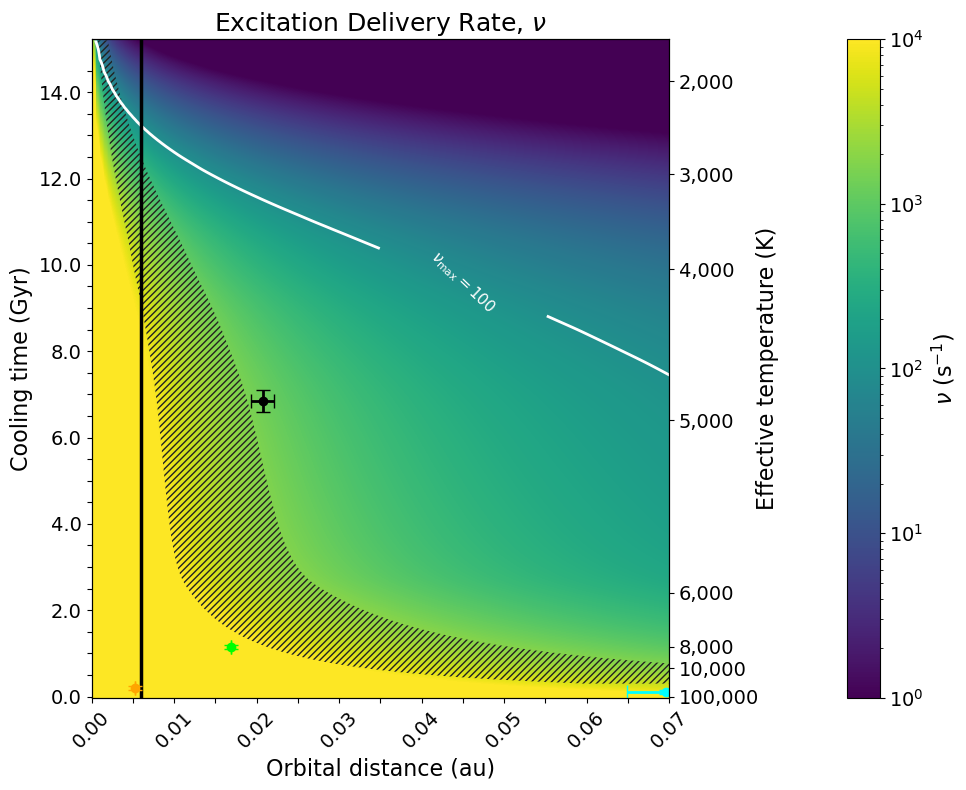

In [13]:
# 2.1 PHOTONS PER S

# Load chosen WD mass cooling curve and pick x evenly spaced temp/age/radius points

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.constants import h, c, Boltzmann as kB

# Load the WD 0.6 Msun data
data = np.loadtxt("WD_060Mo.txt", skiprows=1)
teffs_all, ages_all, radii_all, luminosities_all = data.T  # data.T transposes columns in .txt file into separate arrays in order of appearance 

teffs = teffs_all
radii = radii_all
ages = ages_all

# Choose orbital distance range and number of points 

AU = 1.496e11  # AU in meters
orbital_distances = np.arange(0.0001*AU, 0.155*AU, 0.0005*AU)  # in metres! An array of x orbital distances (in AU) is created, to be later used in "for D in orbital_distances::

# Black body Planck Function (spectral radiance [power per unit area per solid angle or 'steradian' per unit wavelength, in a specific direction])


def B_planck(L, T):
    A = (2.0 * h * c ** 2) / (L ** 5)
    exponent = (h * c) / (L * kB * T)
    return A / (np.exp(exponent) - 1.0)


# Generate stellar surface flux density for each extracted Teff

# Key constants 
AU = 1.496e11
l_range = np.arange(200e-9, 1000e-9, 1e-9)  # Wavelengths in meters
l_nm = l_range * 1e9  # Converts wavelength to nm for use in antenna model

def stellar_surface_flux(T): # at each Teff
    B_lambda = np.pi * B_planck(l_range, T)  # Multiply by pi to convert spectral radiance to stellar surface flux density (power per square meter of the star's surface over all directions, per unit wavelength)
    B_nm = B_lambda * 1e-9 # convert # W/m²/m to # W/m²/nm
    return B_nm


# Generate incident fluxes in Wm^-2nm^-1

def incident_flux(B_nm, R, D):
    F_nm = B_nm * ((R / D) ** 2)
    return F_nm

# Make a grid of orbital distances (#N values) and temp/age/radius (#N values) and run through antenna models.

# Helper functions
def compute_PAR_flux(l_nm, F_nm):
    mask = (l_nm >= 400) & (l_nm <= 700)
    return np.trapz(F_nm[mask], l_nm[mask])

# Simple Photosystem model constants
N_PIGMENTS = 600
SIGMA_PS = 1e-20  # m^2

# Run through simple antenna model
def photon_absorption_rate(l_nm, F_nm):
    l_m = l_nm * 1e-9  # convert nm → m

    # Convert incident flux in W m^-2 nm^-1 (J s^-1 m^-2 nm^-1) to photon flux (#photons m^-2 s^-1 nm^-1)
    photon_flux = (F_nm * l_m) / (h * c)

    # Compute PAR (400–700 nm)
    mask = (l_nm >= 400) & (l_nm <= 700)
    PAR = np.trapz(photon_flux[mask], l_nm[mask])  # integrating removes nm leaving units of photons s^-1 m^-2

    phi = PAR * N_PIGMENTS * SIGMA_PS

    return phi, PAR



# Making the grid of orbital distances (#N values) and temp/age/radius (#N values) and run through antenna models.
results = []  # Make sure to define results as an empty list before the loop
for T, R, A in zip(teffs, radii, ages):  # From Step 1 (note 'T' and 'R' could be any letters, they just refer to each value in the teffs array and radii array made in step 1)
    B_nm = stellar_surface_flux(T)  # From Step 4. Creates stellar surface flux for each Teff now.

    for D in orbital_distances:  # From Step 2 (note 'D' could be any letter, just refers to each value in the orbital_distances array made in step 2)
        F_nm = incident_flux(B_nm, R, D)  # From Step 5. Creates incident flux for each Teff/radius and each orbital distance now.

        phi, PAR_flux = photon_absorption_rate(l_nm, F_nm)

        # Step 7: Store Results
        result = {
            'Teff': T,
            'Radius': R,
            'Age': A,
            'Distance': D,
            'PAR_flux': PAR_flux,
            'phi': phi
        }
        results.append(result)


# Make heatmaps

df = pd.DataFrame(results)
df['Distance_AU'] = df['Distance'] / AU  # Convert Distance from meters to AU

# Create pivot table for heatmap data
heat_data = df.pivot_table(index='Age', columns='Distance_AU', values='phi')
heat_data = heat_data.sort_index(ascending=False)


import matplotlib.colors as mcolors
# Define normalization with center at 0.017
#norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=4500, vmax=9000)
# Then use this norm in imshow

fig, ax = plt.subplots(figsize=(10, 8)) 

norm = LogNorm(vmin=1, vmax=10000)

im = ax.imshow(
    heat_data.values,
    aspect='auto',
    interpolation='bilinear',
    cmap='viridis',
    norm=norm
)
cbar = plt.colorbar(im, ax=ax, pad=0.2)
cbar.set_ticks([1, 10, 100, 1000, 10000])
cbar.set_ticklabels([r'$10^0$', r'$10^1$', r'$10^2$', r'$10^3$', r'$10^4$'])
cbar.set_label(r'$\nu$ (s$^{-1}$)', fontsize=16)
cbar.ax.tick_params(labelsize=14)


contours = ax.contour(
    heat_data.values,
    levels=[100],
    colors='white',
    linewidths=2,
    linestyles='-'
)

ax.clabel(
    contours,
    fmt={100: r'$\nu_{\max} = 100$'},
    inline=True,
    fontsize=11,
    colors='white'
)


# Get age values and indices
ages = heat_data.index.values
tick_values = np.arange(0, 15, 0.5)  # Ticks every 0.5 Gyr
tick_positions = [np.argmin(np.abs(ages - val)) for val in tick_values]
# Set labels only for every 2 Gyr, empty for others
tick_labels = [f"{val:.1f}" if val % 2 == 0 else "" for val in tick_values]
# Apply custom ticks and labels
ax.set_yticks(ticks=tick_positions, labels=tick_labels)


orbital_distances = heat_data.columns.values 
idx_007 = np.searchsorted(orbital_distances, 0.07)
ax.set_xlim(0, idx_007)

x_tick_values = np.concatenate([[0.00], np.linspace(0.005, 0.07, 14)])
x_tick_positions = [np.argmin(np.abs(orbital_distances - val)) for val in x_tick_values]
x_tick_labels = [f"{val:.2f}" if round(val * 1000) % 10 == 0 or val == 0.00 else "" for val in x_tick_values]

ax.set_xticks(ticks=x_tick_positions)
ax.set_xticklabels(x_tick_labels, rotation=45)


ax.set_xlabel('Orbital distance (au)', fontsize=16)
ax.set_ylabel('Cooling time (Gyr)', fontsize=16)
ax.set_title(r'Excitation Delivery Rate, $\nu$', fontsize=18)


ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())

# Get all available Teff values from your data
available_teffs = np.array(sorted(set(teffs_all), reverse=True))  # descending order

# Desired Teff ticks (labels)
desired_teff_ticks = np.array([100000, 10000, 8000, 6000, 5000, 4000, 3000, 2000])

# Get all unique Teff–Age pairs
unique_teff_age = sorted(set(zip(teffs_all, ages_all)), key=lambda x: x[1], reverse=True)  # sort by age descending

# Create arrays
sorted_teffs, sorted_ages = zip(*unique_teff_age)
sorted_teffs = np.array(sorted_teffs)
sorted_ages = np.array(sorted_ages)

# Find closest available Teff to each desired tick
closest_teff_values = [min(sorted_teffs, key=lambda x: abs(x - val)) for val in desired_teff_ticks]

# Get index (row position) in heatmap based on Age that corresponds to each Teff
tick_positions = [np.argmin(np.abs(heat_data.index.values - sorted_ages[np.where(sorted_teffs == teff)[0][0]])) for teff in closest_teff_values]

from matplotlib.ticker import FixedLocator, FixedFormatter

# Explicitly set locator and formatter to avoid default ticks
ax2.yaxis.set_major_locator(FixedLocator(tick_positions))
ax2.yaxis.set_major_formatter(FixedFormatter([f"{val:,}" for val in desired_teff_ticks]))

ax2.set_ylabel('Effective temperature (K)', fontsize=16)
ax2.yaxis.set_label_position("right")
ax2.yaxis.set_label_coords(1.15, 0.5)  # (x, y) relative to axes

# Make axis tick labels bigger
ax.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='y', labelsize=14)


# ADDING ROCHE LIMIT
Pearth = 5.5  # g/cm^3 (Earth-like planetary density)
rho_earth = 5.5  # g/cm^3 (density of Earth)
scaling_factor = 7.27e-3  # Scaling factor for Roche limit in AU
#Msolar = 1.989e30  # Solar mass in kg

# Calculate the Roche limit in AU
Roche_AU = scaling_factor * (Pearth / rho_earth)**(-1/3) * (0.6)**(1/3)
#print(Roche_AU)

# Find insertion position in orbital_distances to keep array sorted
pos = np.searchsorted(orbital_distances, Roche_AU)
#print(pos) # For example, pos might be 1 (since 0.006 is between 0.005 (index 0) and 0.01 (index 1))

# Lower and upper AU bounds for pixels around target_au
lower_au = orbital_distances[pos - 1]
upper_au = orbital_distances[pos]

# Fraction along between those two pixels:
fraction = (Roche_AU - lower_au) / (upper_au - lower_au)

# Corresponding x position for axvline:
x_pos = (pos - 1) + fraction

ax.axvline(x=x_pos, color='black', linestyle='-', linewidth=2.5, alpha=1, label='Roche limit')


# Step 11: ADDING HZ 

A = 0.3
Tplanet_inner = 270.0
Tplanet_outer = 175.0

D_hz_inner = (radii / 2) * (teffs**2 * np.sqrt(1 - A)) / (Tplanet_inner**2)
D_hz_outer = (radii / 2) * (teffs**2 * np.sqrt(1 - A)) / (Tplanet_outer**2)

D_hz_inner_AU = D_hz_inner / AU
D_hz_outer_AU = D_hz_outer / AU

def au_to_xpos(au_vals, orbital_distances): # converts each AU value to a position on a linear scale based on orbital_distances above
    xpos = []
    for au in au_vals:
        if au < orbital_distances[0] or au > orbital_distances[-1]: # if au is out of the orbital distances range insert np.nan
            xpos.append(np.nan)
            continue
        pos = np.searchsorted(orbital_distances, au) # otherwise, find the two orbital distances between which it falls
        if pos == 0:
            xpos.append(0)
            continue
        lower_au = orbital_distances[pos - 1] 
        upper_au = orbital_distances[pos]
        fraction = (au - lower_au) / (upper_au - lower_au) # equivalent to linear interpolation: find two closest values around au (lower and upper), calculate how far au lies between them as a fractional distance
        x = (pos - 1) + fraction # gives a decimal index placing the value between two known points 
        xpos.append(x)
    return np.array(xpos)

# Apply au_to_xpos to the HZ boundaries
hz_inner_x = au_to_xpos(D_hz_inner_AU, orbital_distances)
hz_outer_x = au_to_xpos(D_hz_outer_AU, orbital_distances)

#heatmap_ypos = np.array([np.argmin(np.abs(heat_data.index.values - a)) for a in ages])
# Length of heatmap rows
n_rows = len(heat_data.index)

# Get positions from the reversed index to match heatmap orientation
heatmap_ypos = np.array([np.argmin(np.abs(heat_data.index.values - a)) for a in ages])
heatmap_ypos = n_rows - 1 - heatmap_ypos

#Fill between HZ hatching
ax.fill_betweenx(heatmap_ypos, hz_inner_x, hz_outer_x,facecolor='none', edgecolor='#222222', hatch='/////',linewidth=0.0, label='Habitable Zone')

# Step 12: ADD CROSS ERROR BAR (horizontal and vertical)

x_center_au = 0.02085
x_err_au = 0.0014

# New age-based values in Gyr
y_center_age = 6.850  # midpoint (this is the closest age to 4920 K)
y_err_age = 0.25      # this is the closest age range for the +-50 K around 4920 K

# Convert AU to heatmap x-axis (column) position as before
def au_to_xpos(au_val, orbital_distances):
    pos = np.searchsorted(orbital_distances, au_val)
    if pos == 0:
        return 0
    lower_au = orbital_distances[pos - 1]
    upper_au = orbital_distances[pos]
    fraction = (au_val - lower_au) / (upper_au - lower_au)
    return (pos - 1) + fraction

x_pos_center = au_to_xpos(x_center_au, orbital_distances)
x_pos_err = au_to_xpos(x_center_au + x_err_au, orbital_distances) - x_pos_center

# Convert Age to heatmap y-axis (row) index position
age_values = heat_data.index.values  # assumed sorted descending (e.g., 13.0 -> 0.1)

# Get the row index that best matches the age
y_pos_center = np.argmin(np.abs(age_values - y_center_age))

# Get vertical uncertainty in row index units
y_upper = y_center_age + y_err_age
y_lower = y_center_age - y_err_age

y_pos_upper = np.argmin(np.abs(age_values - y_upper))
y_pos_lower = np.argmin(np.abs(age_values - y_lower))
y_pos_err = abs(y_pos_upper - y_pos_lower) / 2

# Plot the errorbar using row/column index space
ax.errorbar(
    x=x_pos_center,
    y=y_pos_center,
    xerr=x_pos_err,
    yerr=y_pos_err,
    fmt='o',
    color='black',
    elinewidth=2,
    capsize=5,
    label='WD 1856+534 b'
)

# ===============================
# Planet 2: WD 1054-226 b
# ===============================

x_center_au_2 = 0.017     # orbital distance in AU
x_err_au_2    = 0.000

y_center_age_2 = 1.15      # cooling age in Gyr
y_err_age_2    = 0.05

# X-position
x_pos_center_2 = au_to_xpos(x_center_au_2, orbital_distances)
x_pos_err_2 = au_to_xpos(x_center_au_2 + x_err_au_2, orbital_distances) - x_pos_center_2

# Y-position
y_pos_center_2 = np.argmin(np.abs(age_values - y_center_age_2))

y_upper_2 = y_center_age_2 + y_err_age_2
y_lower_2 = y_center_age_2 - y_err_age_2

y_pos_upper_2 = np.argmin(np.abs(age_values - y_upper_2))
y_pos_lower_2 = np.argmin(np.abs(age_values - y_lower_2))
y_pos_err_2 = abs(y_pos_upper_2 - y_pos_lower_2) / 2

# Plot second planet
ax.errorbar(
    x=x_pos_center_2,
    y=y_pos_center_2,
    xerr=x_pos_err_2,
    yerr=y_pos_err_2,
    fmt='o',
    color='lime',
    elinewidth=2,
    capsize=5,
    label='WD 1054-226 b'
)

# ===============================
# Planet 3: WD J0914+1914 b
# ===============================

x_center_au_3 = 0.06975     # orbital distance in AU
x_err_au_3    = 0.0047

y_center_age_3 = 0.1      # cooling age in Gyr
y_err_age_3    = 0.05

# X-position
x_pos_center_3 = au_to_xpos(x_center_au_3, orbital_distances)
x_pos_err_3 = au_to_xpos(x_center_au_3 + x_err_au_3, orbital_distances) - x_pos_center_3

# Y-position
y_pos_center_3 = np.argmin(np.abs(age_values - y_center_age_3))

y_upper_3 = y_center_age_3 + y_err_age_3
y_lower_3 = y_center_age_3 - y_err_age_3

y_pos_upper_3 = np.argmin(np.abs(age_values - y_upper_3))
y_pos_lower_3 = np.argmin(np.abs(age_values - y_lower_3))
y_pos_err_3 = abs(y_pos_upper_3 - y_pos_lower_3) / 2

# Plot third planet
ax.errorbar(
    x=x_pos_center_3,
    y=y_pos_center_3,
    xerr=x_pos_err_3,
    yerr=y_pos_err_3,
    fmt='o',
    color='cyan',
    elinewidth=2,
    capsize=5,
    label='WD J0914+1914 b'
)

# ===============================
# Planet 4: WD 1145+017 b
# ===============================

x_center_au_4 = 0.0054     # orbital distance in AU
x_err_au_4    = 0.0000

y_center_age_4 = 0.2      # cooling age in Gyr
y_err_age_4    = 0.05

# X-position
x_pos_center_4 = au_to_xpos(x_center_au_4, orbital_distances)
x_pos_err_4 = au_to_xpos(x_center_au_4 + x_err_au_4, orbital_distances) - x_pos_center_4

# Y-position
y_pos_center_4 = np.argmin(np.abs(age_values - y_center_age_4))

y_upper_4 = y_center_age_4 + y_err_age_4
y_lower_4 = y_center_age_4 - y_err_age_4

y_pos_upper_4 = np.argmin(np.abs(age_values - y_upper_4))
y_pos_lower_4 = np.argmin(np.abs(age_values - y_lower_4))
y_pos_err_4 = abs(y_pos_upper_4 - y_pos_lower_4) / 2

# Plot fourth planet
ax.errorbar(
    x=x_pos_center_4,
    y=y_pos_center_4,
    xerr=x_pos_err_4,
    yerr=y_pos_err_4,
    fmt='o',
    color='orange',
    elinewidth=2,
    capsize=5,
    label='WD 1145+017 b'
)

plt.tight_layout()
plt.show()

In [15]:
# 2.2 SELECTING PHOTONS PER S

# Filter for x Gyr cooling age (closest match)
target_age = 6.85

# Find closest age row
df_age1 = df.iloc[(df['Age'] - target_age).abs().argsort()[:1]]

# Minimum, average, maximum over all distances and ages (unchanged)
phi_min = df['phi'].min()
phi_avg = df['phi'].mean()
phi_max = df['phi'].max()

# PAR flux at x AU and y Gyr
target_distance = 0.02085
df_target = df.copy()
df_target['dist_diff'] = np.abs(df_target['Distance_AU'] - target_distance)
df_target['age_diff'] = np.abs(df_target['Age'] - target_age)
closest_idx = df_target[['dist_diff', 'age_diff']].sum(axis=1).idxmin()
phi_final = df_target.loc[closest_idx, 'phi']

# Print results
print(f"phi minimum: {phi_min:.2f} photons/s")
print(f"phi average: {phi_avg:.2f} photons/s")
print(f"phi maximum: {phi_max:.2f} photons/s")
print(f"phi at X AU, Y Gyr: {phi_final:.2f} photons/s")

phi minimum: 0.00 photons/s
phi average: 2837190.87 photons/s
phi maximum: 199802364667.64 photons/s
phi at X AU, Y Gyr: 1339.60 photons/s


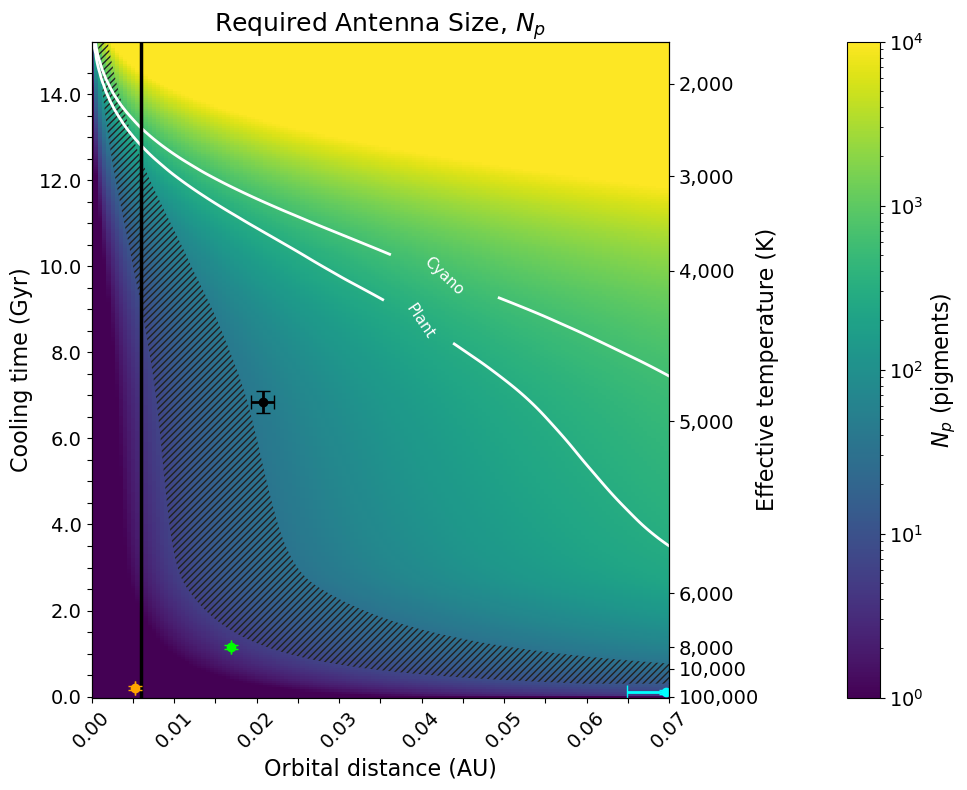

In [23]:
# 3.1 PIGMENTS PER ANTENNA

# Load chosen WD mass cooling curve and pick x evenly spaced temp/age/radius points

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.constants import h, c, Boltzmann as kB

# Load the WD 0.6 Msun data
data = np.loadtxt("WD_060Mo.txt", skiprows=1)
teffs_all, ages_all, radii_all, luminosities_all = data.T  # data.T transposes columns in .txt file into separate arrays in order of appearance 

teffs = teffs_all
radii = radii_all
ages = ages_all

# Choose orbital distance range and number of points 

AU = 1.496e11  # AU in meters
orbital_distances = np.arange(0.0001*AU, 0.155*AU, 0.0005*AU)  # in metres! An array of x orbital distances (in AU) is created, to be later used in "for D in orbital_distances::

#Black body Planck Function (spectral radiance [power per unit area per solid angle or 'steradian' per unit wavelength, in a specific direction])

def B_planck(L, T):
    A = (2.0 * h * c ** 2) / (L ** 5)
    exponent = (h * c) / (L * kB * T)
    return A / (np.exp(exponent) - 1.0)


# Generate stellar surface flux density for each extracted Teff

# Key constants 
AU = 1.496e11
l_range = np.arange(200e-9, 1000e-9, 1e-9)  # Wavelengths in meters
l_nm = l_range * 1e9  # Converts wavelength to nm for use in antenna model

def stellar_surface_flux(T): # at each Teff
    B_lambda = np.pi * B_planck(l_range, T)  # Multiply by pi to convert spectral radiance to stellar surface flux density (power per square meter of the star's surface over all directions, per unit wavelength)
    B_nm = B_lambda * 1e-9 # convert # W/m²/m to # W/m²/nm
    return B_nm


# Generate incident fluxes in Wm^-2nm^-1

def incident_flux(B_nm, R, D):
    F_nm = B_nm * ((R / D) ** 2)
    return F_nm

# Make a grid of orbital distances (#N values) and temp/age/radius (#N values) and run through antenna models.

# Helper functions
def compute_PAR_flux(l_nm, F_nm):
    mask = (l_nm >= 400) & (l_nm <= 700)
    return np.trapz(F_nm[mask], l_nm[mask])

# Simple Photosystem model constants
TARGET_PHI = 100   # photons per second desired
SIGMA_PS = 1e-20  # m^2

# Run through simple antenna model
def required_n_pigments(l_nm, F_nm):
    l_m = l_nm * 1e-9

    photon_flux = (F_nm * l_m) / (h * c)

    mask = (l_nm >= 400) & (l_nm <= 700)
    PAR = np.trapz(photon_flux[mask], l_nm[mask])

    N_pigments = TARGET_PHI / (PAR * SIGMA_PS)

    return N_pigments, PAR


# Making the grid of orbital distances (#N values) and temp/age/radius (#N values) and run through antenna models.
results = []  # Make sure to define results as an empty list before the loop
for T, R, A in zip(teffs, radii, ages):  # From Step 1 (note 'T' and 'R' could be any letters, they just refer to each value in the teffs array and radii array made in step 1)
    B_nm = stellar_surface_flux(T)  # From Step 4. Creates stellar surface flux for each Teff now.

    for D in orbital_distances:  # From Step 2 (note 'D' could be any letter, just refers to each value in the orbital_distances array made in step 2)
        F_nm = incident_flux(B_nm, R, D)  # From Step 5. Creates incident flux for each Teff/radius and each orbital distance now.

        N_pigments, PAR_flux = required_n_pigments(l_nm, F_nm)

        # Step 7: Store Results
        result = {
            'Teff': T,
            'Radius': R,
            'Age': A,
            'Distance': D,
            'PAR_flux': PAR_flux,
            'N_PIGMENTS': N_pigments
        }
        results.append(result)


# Make heatmaps
#import seaborn as sns

df = pd.DataFrame(results)
df['Distance_AU'] = df['Distance'] / AU  # Convert Distance from meters to AU

# Create pivot table for heatmap data
heat_data = df.pivot_table(index='Age', columns='Distance_AU', values='N_PIGMENTS')
heat_data = heat_data.sort_index(ascending=False)

import matplotlib.colors as mcolors


fig, ax = plt.subplots(figsize=(10, 8)) 

cbar.ax.tick_params(labelsize=16) # cbar tick size

norm = LogNorm(vmin=1, vmax=10000)

im = ax.imshow(
    heat_data.values,
    aspect='auto',
    interpolation='nearest',
    cmap='viridis',
    norm=norm
)

cbar = plt.colorbar(im, ax=ax, pad=0.2)
cbar.set_ticks([1, 10, 100, 1000, 10000])
cbar.set_ticklabels([r'$10^0$', r'$10^1$', r'$10^2$', r'$10^3$', r'$10^4$'])
cbar.set_label(r'$N_p$ (pigments)', fontsize=16)
cbar.ax.tick_params(labelsize=14)


# Contours at plant and cyanobacteria antenna sizes
# Plant contour
plant_contour = ax.contour(
    heat_data.values,
    levels=[300],
    colors='white',
    linewidths=2,
    linestyles='-'
)

ax.clabel(
    plant_contour,
    fmt={300: 'Plant'},
    inline=True,
    fontsize=11,
    colors='white',
    manual=[(60, 140)]
)

# Cyanobacteria contour
cyano_contour = ax.contour(
    heat_data.values,
    levels=[600],
    colors='white',
    linewidths=2,
    linestyles='-'
)

ax.clabel(
    cyano_contour,
    fmt={600: 'Cyano'},
    inline=True,
    fontsize=11,
    colors='white',
    manual=[(60, 130)]
)



# Get age values and indices
ages = heat_data.index.values
tick_values = np.arange(0, 15, 0.5)  # Ticks every 0.5 Gyr
tick_positions = [np.argmin(np.abs(ages - val)) for val in tick_values]
# Set labels only for every 2 Gyr, empty for others
tick_labels = [f"{val:.1f}" if val % 2 == 0 else "" for val in tick_values]
# Apply custom ticks and labels
ax.set_yticks(ticks=tick_positions, labels=tick_labels)

ax.set_xlim(0.0001, 0.10)

orbital_distances = heat_data.columns.values 
idx_007 = np.searchsorted(orbital_distances, 0.07)
ax.set_xlim(0, idx_007)

x_tick_values = np.concatenate([[0.00], np.linspace(0.005, 0.07, 14)])
x_tick_positions = [np.argmin(np.abs(orbital_distances - val)) for val in x_tick_values]
x_tick_labels = [f"{val:.2f}" if round(val * 1000) % 10 == 0 or val == 0.00 else "" for val in x_tick_values]

ax.set_xticks(ticks=x_tick_positions)
ax.set_xticklabels(x_tick_labels, rotation=45)


ax.set_xlabel('Orbital distance (AU)', fontsize=16)
ax.set_ylabel('Cooling time (Gyr)', fontsize=16)
ax.set_title(r'Required Antenna Size, $N_p$', fontsize=18)


ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())

# Get all available Teff values from your data
available_teffs = np.array(sorted(set(teffs_all), reverse=True))  # descending order

# Desired Teff ticks (labels)
desired_teff_ticks = np.array([100000, 10000, 8000, 6000, 5000, 4000, 3000, 2000])

# Get all unique Teff–Age pairs
unique_teff_age = sorted(set(zip(teffs_all, ages_all)), key=lambda x: x[1], reverse=True)  # sort by age descending

# Create arrays
sorted_teffs, sorted_ages = zip(*unique_teff_age)
sorted_teffs = np.array(sorted_teffs)
sorted_ages = np.array(sorted_ages)

# Find closest available Teff to each desired tick
closest_teff_values = [min(sorted_teffs, key=lambda x: abs(x - val)) for val in desired_teff_ticks]

# Get index (row position) in heatmap based on Age that corresponds to each Teff
tick_positions = [np.argmin(np.abs(heat_data.index.values - sorted_ages[np.where(sorted_teffs == teff)[0][0]])) for teff in closest_teff_values]

from matplotlib.ticker import FixedLocator, FixedFormatter

# Explicitly set locator and formatter to avoid default ticks
ax2.yaxis.set_major_locator(FixedLocator(tick_positions))
ax2.yaxis.set_major_formatter(FixedFormatter([f"{val:,}" for val in desired_teff_ticks]))

ax2.set_ylabel('Effective temperature (K)', fontsize=16)
ax2.yaxis.set_label_position("right")
ax2.yaxis.set_label_coords(1.15, 0.5)  # (x, y) relative to axes

# Make axis tick labels bigger
ax.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='y', labelsize=14)


# ADDING ROCHE LIMIT
Pearth = 5.5  # g/cm^3 (Earth-like planetary density)
rho_earth = 5.5  # g/cm^3 (density of Earth)
scaling_factor = 7.27e-3  # Scaling factor for Roche limit in AU
#Msolar = 1.989e30  # Solar mass in kg

# Calculate the Roche limit in AU
Roche_AU = scaling_factor * (Pearth / rho_earth)**(-1/3) * (0.6)**(1/3)
#print(Roche_AU)

# Find insertion position in orbital_distances to keep array sorted
pos = np.searchsorted(orbital_distances, Roche_AU)
#print(pos) # For example, pos might be 1 (since 0.006 is between 0.005 (index 0) and 0.01 (index 1))

# Lower and upper AU bounds for pixels around target_au
lower_au = orbital_distances[pos - 1]
upper_au = orbital_distances[pos]

# Fraction along between those two pixels:
fraction = (Roche_AU - lower_au) / (upper_au - lower_au)

# Corresponding x position for axvline:
x_pos = (pos - 1) + fraction

ax.axvline(x=x_pos, color='black', linestyle='-', linewidth=2.5, alpha=1, label='Roche limit')


# ADDING HZ 

A = 0.3
Tplanet_inner = 270.0
Tplanet_outer = 175.0

D_hz_inner = (radii / 2) * (teffs**2 * np.sqrt(1 - A)) / (Tplanet_inner**2)
D_hz_outer = (radii / 2) * (teffs**2 * np.sqrt(1 - A)) / (Tplanet_outer**2)

D_hz_inner_AU = D_hz_inner / AU
D_hz_outer_AU = D_hz_outer / AU


def au_to_xpos(au_vals, orbital_distances): # converts each AU value to a position on a linear scale based on orbital_distances above
    xpos = []
    for au in au_vals:
        if au < orbital_distances[0] or au > orbital_distances[-1]: # if au is out of the orbital distances range insert np.nan
            xpos.append(np.nan)
            continue
        pos = np.searchsorted(orbital_distances, au) # otherwise, find the two orbital distances between which it falls
        if pos == 0:
            xpos.append(0)
            continue
        lower_au = orbital_distances[pos - 1] 
        upper_au = orbital_distances[pos]
        fraction = (au - lower_au) / (upper_au - lower_au) # equivalent to linear interpolation: find two closest values around au (lower and upper), calculate how far au lies between them as a fractional distance
        x = (pos - 1) + fraction # gives a decimal index placing the value between two known points 
        xpos.append(x)
    return np.array(xpos)

# Apply au_to_xpos to the HZ boundaries
hz_inner_x = au_to_xpos(D_hz_inner_AU, orbital_distances)
hz_outer_x = au_to_xpos(D_hz_outer_AU, orbital_distances)

#heatmap_ypos = np.array([np.argmin(np.abs(heat_data.index.values - a)) for a in ages])
# Length of heatmap rows
n_rows = len(heat_data.index)

# Get positions from the reversed index to match heatmap orientation
heatmap_ypos = np.array([np.argmin(np.abs(heat_data.index.values - a)) for a in ages])
heatmap_ypos = n_rows - 1 - heatmap_ypos

#Fill between HZ hatching
ax.fill_betweenx(heatmap_ypos, hz_inner_x, hz_outer_x,facecolor='none', edgecolor='#222222', hatch='/////',linewidth=0.0, label='Habitable Zone')
# Step 12: ADD CROSS ERROR BAR (horizontal and vertical)

x_center_au = 0.02085
x_err_au = 0.0014

# New age-based values in Gyr
y_center_age = 6.850  # midpoint (this is the closest age to 4920 K)
y_err_age = 0.25      # this is the closest age range for the +-50 K around 4920 K

# Convert AU to heatmap x-axis (column) position as before
def au_to_xpos(au_val, orbital_distances):
    pos = np.searchsorted(orbital_distances, au_val)
    if pos == 0:
        return 0
    lower_au = orbital_distances[pos - 1]
    upper_au = orbital_distances[pos]
    fraction = (au_val - lower_au) / (upper_au - lower_au)
    return (pos - 1) + fraction

x_pos_center = au_to_xpos(x_center_au, orbital_distances)
x_pos_err = au_to_xpos(x_center_au + x_err_au, orbital_distances) - x_pos_center

# Convert Age to heatmap y-axis (row) index position
age_values = heat_data.index.values  # assumed sorted descending (e.g., 13.0 -> 0.1)

# Get the row index that best matches the age
y_pos_center = np.argmin(np.abs(age_values - y_center_age))

# Get vertical uncertainty in row index units
y_upper = y_center_age + y_err_age
y_lower = y_center_age - y_err_age

y_pos_upper = np.argmin(np.abs(age_values - y_upper))
y_pos_lower = np.argmin(np.abs(age_values - y_lower))
y_pos_err = abs(y_pos_upper - y_pos_lower) / 2

# Plot the errorbar using row/column index space
ax.errorbar(
    x=x_pos_center,
    y=y_pos_center,
    xerr=x_pos_err,
    yerr=y_pos_err,
    fmt='o',
    color='black',
    elinewidth=2,
    capsize=5,
    label='WD 1856+534 b'
)

# ===============================
# Planet 2: WD 1054-226 b
# ===============================

x_center_au_2 = 0.017     # orbital distance in AU
x_err_au_2    = 0.000

y_center_age_2 = 1.15      # cooling age in Gyr
y_err_age_2    = 0.05

# X-position
x_pos_center_2 = au_to_xpos(x_center_au_2, orbital_distances)
x_pos_err_2 = au_to_xpos(x_center_au_2 + x_err_au_2, orbital_distances) - x_pos_center_2

# Y-position
y_pos_center_2 = np.argmin(np.abs(age_values - y_center_age_2))

y_upper_2 = y_center_age_2 + y_err_age_2
y_lower_2 = y_center_age_2 - y_err_age_2

y_pos_upper_2 = np.argmin(np.abs(age_values - y_upper_2))
y_pos_lower_2 = np.argmin(np.abs(age_values - y_lower_2))
y_pos_err_2 = abs(y_pos_upper_2 - y_pos_lower_2) / 2

# Plot second planet
ax.errorbar(
    x=x_pos_center_2,
    y=y_pos_center_2,
    xerr=x_pos_err_2,
    yerr=y_pos_err_2,
    fmt='o',
    color='lime',
    elinewidth=2,
    capsize=5,
    label='WD 1054-226 b'
)

# ===============================
# Planet 3: WD J0914+1914 b
# ===============================

x_center_au_3 = 0.06975     # orbital distance in AU
x_err_au_3    = 0.0047

y_center_age_3 = 0.1      # cooling age in Gyr
y_err_age_3    = 0.05

# X-position
x_pos_center_3 = au_to_xpos(x_center_au_3, orbital_distances)
x_pos_err_3 = au_to_xpos(x_center_au_3 + x_err_au_3, orbital_distances) - x_pos_center_3

# Y-position
y_pos_center_3 = np.argmin(np.abs(age_values - y_center_age_3))

y_upper_3 = y_center_age_3 + y_err_age_3
y_lower_3 = y_center_age_3 - y_err_age_3

y_pos_upper_3 = np.argmin(np.abs(age_values - y_upper_3))
y_pos_lower_3 = np.argmin(np.abs(age_values - y_lower_3))
y_pos_err_3 = abs(y_pos_upper_3 - y_pos_lower_3) / 2

# Plot third planet
ax.errorbar(
    x=x_pos_center_3,
    y=y_pos_center_3,
    xerr=x_pos_err_3,
    yerr=y_pos_err_3,
    fmt='o',
    color='cyan',
    elinewidth=2,
    capsize=5,
    label='WD J0914+1914 b'
)

# ===============================
# Planet 4: WD 1145+017 b
# ===============================

x_center_au_4 = 0.0054     # orbital distance in AU
x_err_au_4    = 0.0000

y_center_age_4 = 0.2      # cooling age in Gyr
y_err_age_4    = 0.05

# X-position
x_pos_center_4 = au_to_xpos(x_center_au_4, orbital_distances)
x_pos_err_4 = au_to_xpos(x_center_au_4 + x_err_au_4, orbital_distances) - x_pos_center_4

# Y-position
y_pos_center_4 = np.argmin(np.abs(age_values - y_center_age_4))

y_upper_4 = y_center_age_4 + y_err_age_4
y_lower_4 = y_center_age_4 - y_err_age_4

y_pos_upper_4 = np.argmin(np.abs(age_values - y_upper_4))
y_pos_lower_4 = np.argmin(np.abs(age_values - y_lower_4))
y_pos_err_4 = abs(y_pos_upper_4 - y_pos_lower_4) / 2

# Plot fourth planet
ax.errorbar(
    x=x_pos_center_4,
    y=y_pos_center_4,
    xerr=x_pos_err_4,
    yerr=y_pos_err_4,
    fmt='o',
    color='orange',
    elinewidth=2,
    capsize=5,
    label='WD 1145+017 b'
)

plt.tight_layout()
plt.show()

In [25]:
# 3.2 SELECTING PHOTONS PER S

# Filter for x Gyr cooling age (closest match)
target_age = 6.85

# Find closest age row
df_age1 = df.iloc[(df['Age'] - target_age).abs().argsort()[:1]]

# Minimum, average, maximum over all distances and ages (unchanged)
N_min = df['N_PIGMENTS'].min()
N_avg = df['N_PIGMENTS'].mean()
N_max = df['N_PIGMENTS'].max()

# PAR flux at x AU and y Gyr
target_distance = 0.02085
df_target = df.copy()
df_target['dist_diff'] = np.abs(df_target['Distance_AU'] - target_distance)
df_target['age_diff'] = np.abs(df_target['Age'] - target_age)
closest_idx = df_target[['dist_diff', 'age_diff']].sum(axis=1).idxmin()
N_final = df_target.loc[closest_idx, 'N_PIGMENTS']

# Print results
print(f"N minimum: {N_min:.2f} pigments")
print(f"N average: {N_avg:.2f} pigments")
print(f"N maximum: {N_max:.2f} pigments")
print(f"N at X AU, Y Gyr: {N_final:.2f} pigments")

N minimum: 0.00 pigments
N average: 362011.80 pigments
N maximum: 42520263.53 pigments
N at X AU, Y Gyr: 44.79 pigments


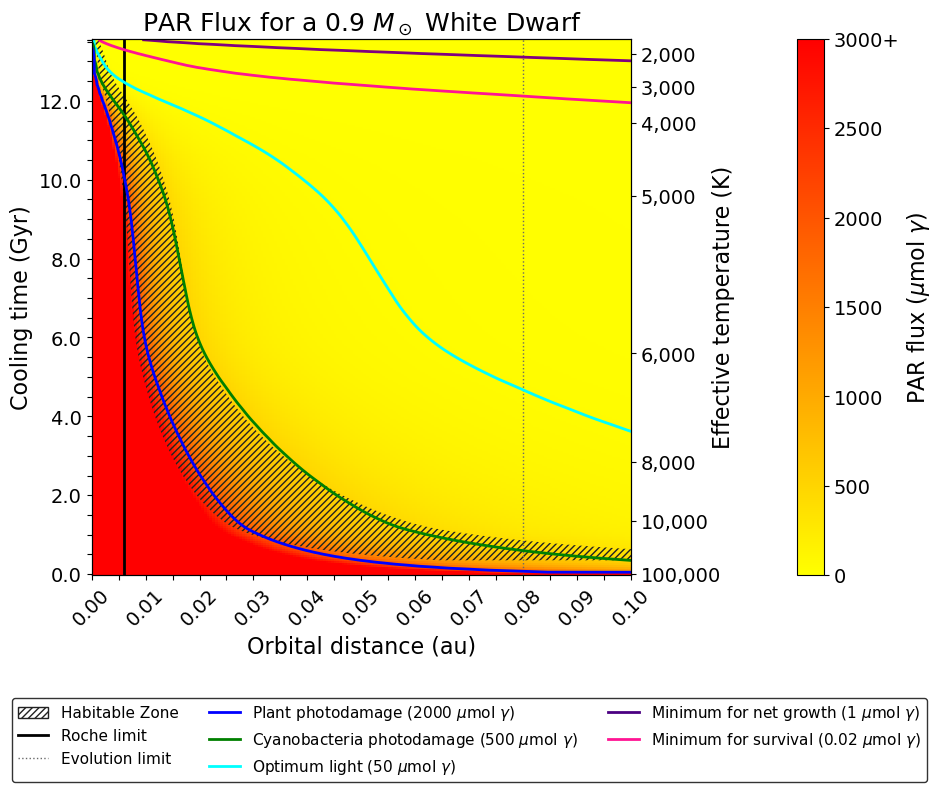

In [31]:
# 0.9Mo WD PAR flux

## Using simple model of a Photosystem and WD flux to calculate PAR flux and various photosynthetic measures

# Load chosen WD mass cooling curve and pick x evenly spaced temp/age/radius points

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.constants import h, c, Boltzmann as kB

# Load the WD 0.6 Msun data
data = np.loadtxt("WD_090Mo.txt", skiprows=1)
teffs_all, ages_all, radii_all, luminosities_all = data.T  # data.T transposes columns in .txt file into separate arrays in order of appearance 

# Choose x evenly spaced samples
teffs = teffs_all
radii = radii_all
ages = ages_all

# Choose orbital distance range and number of points 

AU = 1.496e11  # AU in meters
orbital_distances = np.arange(0.0001*AU, 0.155*AU, 0.0005*AU)  # in metres! An array of x orbital distances (in AU) is created, to be later used in "for D in orbital_distances::

# Black body Planck Function (spectral radiance [power per unit area per solid angle or 'steradian' per unit wavelength, in a specific direction])

def B_planck(L, T):
    A = (2.0 * h * c ** 2) / (L ** 5)
    exponent = (h * c) / (L * kB * T)
    return A / (np.exp(exponent) - 1.0)


# Generate stellar surface flux density for each extracted Teff

# Key constants 
AU = 1.496e11
l_range = np.arange(200e-9, 1000e-9, 1e-9)  # Wavelengths in meters
l_nm = l_range * 1e9  # Converts wavelength to nm for use in antenna model

def stellar_surface_flux(T): # at each Teff
    B_lambda = np.pi * B_planck(l_range, T)  # Multiply by pi to convert spectral radiance to stellar surface flux density (power per square meter of the star's surface over all directions, per unit wavelength)
    B_nm = B_lambda * 1e-9 # convert # W/m²/m to # W/m²/nm
    return B_nm


# Generate incident fluxes in Wm^-2nm^-1

def incident_flux(B_nm, R, D):
    F_nm = B_nm * ((R / D) ** 2)
    return F_nm

# Make a grid of orbital distances (#N values) and temp/age/radius (#N values) and run through antenna models.

# Helper functions
def compute_PAR_flux(l_nm, F_nm):
    mask = (l_nm >= 400) & (l_nm <= 700)
    return np.trapz(F_nm[mask], l_nm[mask])

# Run through simple antenna model
def uE_PAR_flux(l_nm, F_nm):
    l_m = l_nm * 1e-9  # convert nm → m

    # Convert incident flux in W m^-2 nm^-1 (J s^-1 m^-2 nm^-1) to photon flux (#photons m^-2 s^-1 nm^-1)
    photon_flux = (F_nm * l_m) / (h * c)
    photon_flux_uE = photon_flux / 6.02e17 #convert photon flux (#photons m^-2 s^-1 nm^-1) to uE (umol photons m^-2 s^-1 nm^-1)

    # Compute PAR (400–700 nm)
    mask = (l_nm >= 400) & (l_nm <= 700)
    PAR = np.trapz(photon_flux_uE[mask], l_nm[mask])  # integrating removes nm leaving units of umol photons s^-1 m^-2

    return PAR


# Making the grid of orbital distances (#N values) and temp/age/radius (#N values) and run through antenna models.
results = []  # Make sure to define results as an empty list before the loop
for T, R, A in zip(teffs, radii, ages):  # From Step 1 (note 'T' and 'R' could be any letters, they just refer to each value in the teffs array and radii array made in step 1)
    B_nm = stellar_surface_flux(T)  # From Step 4. Creates stellar surface flux for each Teff now.

    for D in orbital_distances:  # From Step 2 (note 'D' could be any letter, just refers to each value in the orbital_distances array made in step 2)
        F_nm = incident_flux(B_nm, R, D)  # From Step 5. Creates incident flux for each Teff/radius and each orbital distance now.

        PAR_flux = uE_PAR_flux(l_nm, F_nm)

        # Step 7: Store Results
        result = {
            'Teff': T,
            'Radius': R,
            'Age': A,
            'Distance': D,
            'PAR_flux': PAR_flux,
        }
        results.append(result)


# Make heatmaps

df = pd.DataFrame(results)
df['Distance_AU'] = df['Distance'] / AU  # Convert Distance from meters to AU

# Create pivot table for heatmap data
heat_data = df.pivot_table(index='Age', columns='Distance_AU', values='PAR_flux')
heat_data = heat_data.sort_index(ascending=False)

cmap = plt.get_cmap('autumn_r')

import matplotlib.colors as mcolors

# Define normalization with center at 0.017
norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=1500, vmax=3000)
# Then use this norm in imshow
fig, ax = plt.subplots(figsize=(10, 8.5)) 
im = ax.imshow(
    heat_data.values, 
    #subset.values,
    aspect='auto', 
    interpolation='nearest',  # or 'bicubic', 'nearest', etc.
    cmap=cmap,
    norm=norm
)

# Create and customize colorbar
cbar = plt.colorbar(im, ax=ax, pad=0.2)
cbar.set_ticks([0, 500, 1000, 1500, 2000, 2500, 3000])
cbar.set_ticklabels(['0', '500', '1000', '1500', '2000', '2500', '3000+'])
cbar.set_label(r'PAR flux ($\mu$mol $\gamma$)', fontsize=16)
cbar.ax.tick_params(labelsize=14) # cbar tick size

# Get age values and indices
ages = heat_data.index.values
tick_values = np.arange(0, 15, 0.5)  # Ticks every 0.5 Gyr
tick_positions = [np.argmin(np.abs(ages - val)) for val in tick_values]
# Set labels only for every 2 Gyr, empty for others
tick_labels = [f"{val:.1f}" if val % 2 == 0 else "" for val in tick_values]
# Apply custom ticks and labels
ax.set_yticks(ticks=tick_positions, labels=tick_labels)

orbital_distances = heat_data.columns.values 

# Start with 0.00 manually, then generate the rest
x_tick_values = np.concatenate([[0.00], np.linspace(0.005, 0.10, 20)])
x_tick_positions = [np.argmin(np.abs(orbital_distances - val)) for val in x_tick_values]
x_tick_labels = [f"{val:.2f}" if round(val * 1000) % 10 == 0 or val == 0.00 else "" for val in x_tick_values]
cbar.ax.tick_params(labelsize=14)

ax.set_xticks(ticks=x_tick_positions)
ax.set_xticklabels(x_tick_labels, rotation=45)

idx_010 = np.searchsorted(heat_data.columns.values, 0.10)
ax.set_xlim(0, idx_010)


ax.set_xlabel('Orbital distance (au)', fontsize=16)
ax.set_ylabel('Cooling time (Gyr)', fontsize=16)
ax.set_title(r'PAR Flux for a 0.9 $M_\odot$ White Dwarf', fontsize=18)

ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())

# Get all available Teff values from your data
available_teffs = np.array(sorted(set(teffs_all), reverse=True))  # descending order

# Desired Teff ticks (labels)
desired_teff_ticks = np.array([100000, 10000, 8000, 6000, 5000, 4000, 3000, 2000])

# Get all unique Teff–Age pairs
unique_teff_age = sorted(set(zip(teffs_all, ages_all)), key=lambda x: x[1], reverse=True)  # sort by age descending

# Create arrays
sorted_teffs, sorted_ages = zip(*unique_teff_age)
sorted_teffs = np.array(sorted_teffs)
sorted_ages = np.array(sorted_ages)

# Find closest available Teff to each desired tick
closest_teff_values = [min(sorted_teffs, key=lambda x: abs(x - val)) for val in desired_teff_ticks]

# Get index (row position) in heatmap based on Age that corresponds to each Teff
tick_positions = [np.argmin(np.abs(heat_data.index.values - sorted_ages[np.where(sorted_teffs == teff)[0][0]])) for teff in closest_teff_values]

from matplotlib.ticker import FixedLocator, FixedFormatter

# Explicitly set locator and formatter to avoid default ticks
ax2.yaxis.set_major_locator(FixedLocator(tick_positions))
ax2.yaxis.set_major_formatter(FixedFormatter([f"{val:,}" for val in desired_teff_ticks]))

ax2.set_ylabel('Effective temperature (K)', fontsize=16)
ax2.yaxis.set_label_position("right")
ax2.yaxis.set_label_coords(1.15, 0.5)  # (x, y) relative to axes

# Make axis tick labels bigger
ax.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='y', labelsize=14)


# ADDING ROCHE LIMIT
Pearth = 5.5  # g/cm^3 (Earth-like planetary density)
rho_earth = 5.5  # g/cm^3 (density of Earth)
scaling_factor = 7.27e-3  # Scaling factor for Roche limit in AU
#Msolar = 1.989e30  # Solar mass in kg

# Calculate the Roche limit in AU
Roche_AU = scaling_factor * (Pearth / rho_earth)**(-1/3) * (0.6)**(1/3)
#print(Roche_AU)

# Find insertion position in orbital_distances to keep array sorted
pos = np.searchsorted(orbital_distances, Roche_AU)
#print(pos) # For example, pos might be 1 (since 0.006 is between 0.005 (index 0) and 0.01 (index 1))

# Lower and upper AU bounds for pixels around target_au
lower_au = orbital_distances[pos - 1]
upper_au = orbital_distances[pos]

# Fraction along between those two pixels:
fraction = (Roche_AU - lower_au) / (upper_au - lower_au)

# Corresponding x position for axvline:
x_pos = (pos - 1) + fraction

ax.axvline(x=x_pos, color='black', linestyle='-', linewidth=2, alpha=1, label='Roche limit')


# ADDING HZ 

A = 0.3
Tplanet_inner = 270.0
Tplanet_outer = 175.0

D_hz_inner = (radii / 2) * (teffs**2 * np.sqrt(1 - A)) / (Tplanet_inner**2)
D_hz_outer = (radii / 2) * (teffs**2 * np.sqrt(1 - A)) / (Tplanet_outer**2)

D_hz_inner_AU = D_hz_inner / AU
D_hz_outer_AU = D_hz_outer / AU

def au_to_xpos(au_vals, orbital_distances):
    scalar_input = np.isscalar(au_vals)
    au_vals = np.atleast_1d(au_vals)

    xpos = []
    for au in au_vals:
        if au < orbital_distances[0] or au > orbital_distances[-1]:
            xpos.append(np.nan)
            continue

        pos = np.searchsorted(orbital_distances, au)

        if pos == 0:
            xpos.append(0)
            continue

        lower_au = orbital_distances[pos - 1]
        upper_au = orbital_distances[pos]

        fraction = (au - lower_au) / (upper_au - lower_au)
        xpos.append((pos - 1) + fraction)

    xpos = np.array(xpos)

    return xpos[0] if scalar_input else xpos

# Apply au_to_xpos to the HZ boundaries
hz_inner_x = au_to_xpos(D_hz_inner_AU, orbital_distances)
hz_outer_x = au_to_xpos(D_hz_outer_AU, orbital_distances)

#heatmap_ypos = np.array([np.argmin(np.abs(heat_data.index.values - a)) for a in ages])
# Length of heatmap rows
n_rows = len(heat_data.index)

# Get positions from the reversed index to match heatmap orientation
heatmap_ypos = np.array([np.argmin(np.abs(heat_data.index.values - a)) for a in ages])
heatmap_ypos = n_rows - 1 - heatmap_ypos

#Fill between HZ hatching
ax.fill_betweenx(heatmap_ypos, hz_inner_x, hz_outer_x,facecolor='none', edgecolor='#222222', hatch='/////',linewidth=0.0, label='Habitable Zone')

#Adding evolutionary limit
target_au = 0.080

x_pos_080 = au_to_xpos(target_au, orbital_distances)

ax.axvline(
    x=x_pos_080,
    color='dimgrey',
    linestyle=':',
    linewidth=1.0
)

# Add PAR threshold contours
levels = [0.02, 1, 50, 500, 2000]

colors = [
    'purple',   # 0.02 μE
    'deeppink',   # 1 μE
    'cyan',     # 50 μE
    'green',    # 500 μE
    'blue'      # 2000 μE
]

contours = ax.contour(
    heat_data.values,
    levels=levels,
    colors=colors,
    linewidths=2
)


from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_handles = [
    Patch(facecolor='none', edgecolor='#222222', hatch='/////', label='Habitable Zone'),
    Line2D([0], [0], color='black', lw=2, label='Roche limit'),
    Line2D([0], [0], color='dimgrey', lw=1, linestyle=':', label='Evolution limit'),

    Line2D([0], [0], color='blue', lw=2, label='Plant photodamage (2000 $\mu$mol $\gamma$)'),
    Line2D([0], [0], color='green', lw=2, label='Cyanobacteria photodamage (500 $\mu$mol $\gamma$)'),
    Line2D([0], [0], color='cyan', lw=2, label='Optimum light (50 $\mu$mol $\gamma$)'),
    Line2D([0], [0], color='indigo', lw=2, label='Minimum for net growth (1 $\mu$mol $\gamma$)'),
    Line2D([0], [0], color='deeppink', lw=2, label='Minimum for survival (0.02 $\mu$mol $\gamma$)'),
]

ax.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.70, -0.40),
    fontsize=11,
    facecolor='white',
    edgecolor='black',
    ncol=3
)

plt.tight_layout()
plt.show()



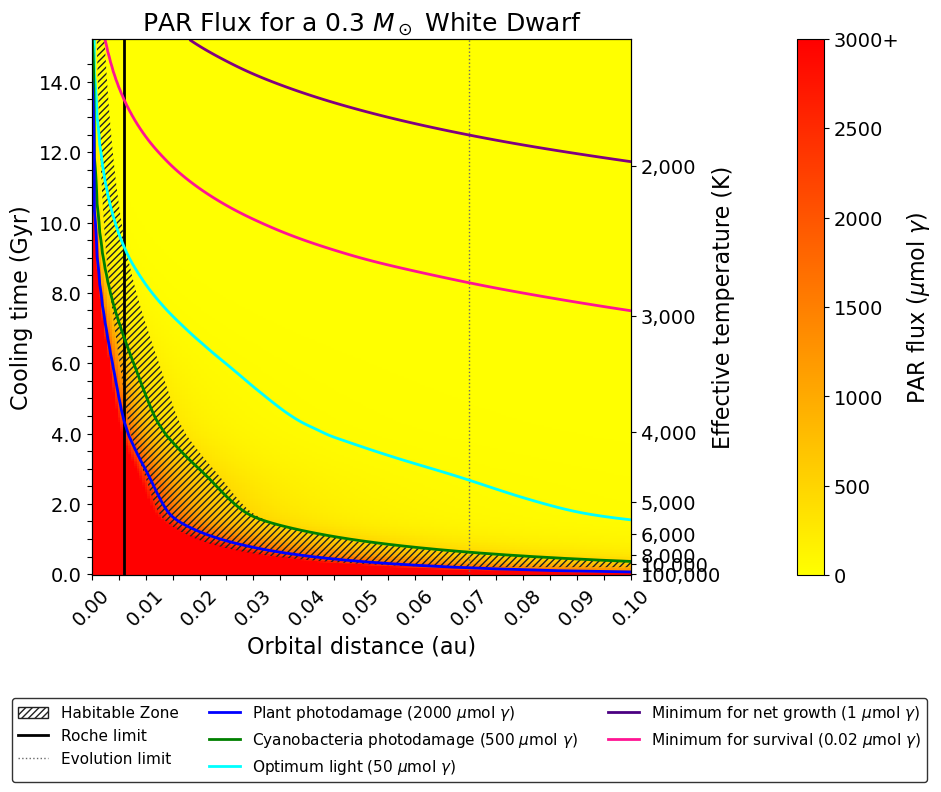

In [46]:
# 0.3Mo WD PAR flux

## Using simple model of a Photosystem and WD flux to calculate PAR flux and various photosynthetic measures

# Load chosen WD mass cooling curve and pick x evenly spaced temp/age/radius points

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.constants import h, c, Boltzmann as kB

# Load the WD 0.6 Msun data
data = np.loadtxt("WD_030Mo.txt", skiprows=1)
teffs_all, ages_all, radii_all, luminosities_all = data.T  # data.T transposes columns in .txt file into separate arrays in order of appearance 

# Choose x evenly spaced samples
teffs = teffs_all
radii = radii_all
ages = ages_all

# Choose orbital distance range and number of points 

AU = 1.496e11  # AU in meters
orbital_distances = np.arange(0.0001*AU, 0.155*AU, 0.0005*AU)  # in metres! An array of x orbital distances (in AU) is created, to be later used in "for D in orbital_distances::

# Black body Planck Function (spectral radiance [power per unit area per solid angle or 'steradian' per unit wavelength, in a specific direction])

def B_planck(L, T):
    A = (2.0 * h * c ** 2) / (L ** 5)
    exponent = (h * c) / (L * kB * T)
    return A / (np.exp(exponent) - 1.0)


# Generate stellar surface flux density for each extracted Teff

# Key constants 
AU = 1.496e11
l_range = np.arange(200e-9, 1000e-9, 1e-9)  # Wavelengths in meters
l_nm = l_range * 1e9  # Converts wavelength to nm for use in antenna model

def stellar_surface_flux(T): # at each Teff
    B_lambda = np.pi * B_planck(l_range, T)  # Multiply by pi to convert spectral radiance to stellar surface flux density (power per square meter of the star's surface over all directions, per unit wavelength)
    B_nm = B_lambda * 1e-9 # convert # W/m²/m to # W/m²/nm
    return B_nm


# Generate incident fluxes in Wm^-2nm^-1

def incident_flux(B_nm, R, D):
    F_nm = B_nm * ((R / D) ** 2)
    return F_nm

# Make a grid of orbital distances (#N values) and temp/age/radius (#N values) and run through antenna models.

# Helper functions
def compute_PAR_flux(l_nm, F_nm):
    mask = (l_nm >= 400) & (l_nm <= 700)
    return np.trapz(F_nm[mask], l_nm[mask])

# Run through simple antenna model
def uE_PAR_flux(l_nm, F_nm):
    l_m = l_nm * 1e-9  # convert nm → m

    # Convert incident flux in W m^-2 nm^-1 (J s^-1 m^-2 nm^-1) to photon flux (#photons m^-2 s^-1 nm^-1)
    photon_flux = (F_nm * l_m) / (h * c)
    photon_flux_uE = photon_flux / 6.02e17 #convert photon flux (#photons m^-2 s^-1 nm^-1) to uE (umol photons m^-2 s^-1 nm^-1)

    # Compute PAR (400–700 nm)
    mask = (l_nm >= 400) & (l_nm <= 700)
    PAR = np.trapz(photon_flux_uE[mask], l_nm[mask])  # integrating removes nm leaving units of umol photons s^-1 m^-2

    return PAR


# Making the grid of orbital distances (#N values) and temp/age/radius (#N values) and run through antenna models.
results = []  # Make sure to define results as an empty list before the loop
for T, R, A in zip(teffs, radii, ages):  # From Step 1 (note 'T' and 'R' could be any letters, they just refer to each value in the teffs array and radii array made in step 1)
    B_nm = stellar_surface_flux(T)  # From Step 4. Creates stellar surface flux for each Teff now.

    for D in orbital_distances:  # From Step 2 (note 'D' could be any letter, just refers to each value in the orbital_distances array made in step 2)
        F_nm = incident_flux(B_nm, R, D)  # From Step 5. Creates incident flux for each Teff/radius and each orbital distance now.

        PAR_flux = uE_PAR_flux(l_nm, F_nm)

        # Step 7: Store Results
        result = {
            'Teff': T,
            'Radius': R,
            'Age': A,
            'Distance': D,
            'PAR_flux': PAR_flux,
        }
        results.append(result)


# Make heatmaps

df = pd.DataFrame(results)
df['Distance_AU'] = df['Distance'] / AU  # Convert Distance from meters to AU

# Create pivot table for heatmap data
heat_data = df.pivot_table(index='Age', columns='Distance_AU', values='PAR_flux')
heat_data = heat_data.sort_index(ascending=False)

cmap = plt.get_cmap('autumn_r')

import matplotlib.colors as mcolors

# Define normalization with center at 0.017
norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=1500, vmax=3000)
# Then use this norm in imshow
fig, ax = plt.subplots(figsize=(10, 8.5)) 
im = ax.imshow(
    heat_data.values, 
    #subset.values,
    aspect='auto', 
    interpolation='nearest',  # or 'bicubic', 'nearest', etc.
    cmap=cmap,
    norm=norm
)

# Create and customize colorbar
cbar = plt.colorbar(im, ax=ax, pad=0.2)
cbar.set_ticks([0, 500, 1000, 1500, 2000, 2500, 3000])
cbar.set_ticklabels(['0', '500', '1000', '1500', '2000', '2500', '3000+'])
cbar.set_label(r'PAR flux ($\mu$mol $\gamma$)', fontsize=16)
cbar.ax.tick_params(labelsize=14) # cbar tick size

# Get age values and indices
ages = heat_data.index.values
tick_values = np.arange(0, 15, 0.5)  # Ticks every 0.5 Gyr
tick_positions = [np.argmin(np.abs(ages - val)) for val in tick_values]
# Set labels only for every 2 Gyr, empty for others
tick_labels = [f"{val:.1f}" if val % 2 == 0 else "" for val in tick_values]
# Apply custom ticks and labels
ax.set_yticks(ticks=tick_positions, labels=tick_labels)

orbital_distances = heat_data.columns.values 

# Start with 0.00 manually, then generate the rest
x_tick_values = np.concatenate([[0.00], np.linspace(0.005, 0.10, 20)])
x_tick_positions = [np.argmin(np.abs(orbital_distances - val)) for val in x_tick_values]
x_tick_labels = [f"{val:.2f}" if round(val * 1000) % 10 == 0 or val == 0.00 else "" for val in x_tick_values]
cbar.ax.tick_params(labelsize=14)

ax.set_xticks(ticks=x_tick_positions)
ax.set_xticklabels(x_tick_labels, rotation=45)

idx_010 = np.searchsorted(heat_data.columns.values, 0.10)
ax.set_xlim(0, idx_010)


ax.set_xlabel('Orbital distance (au)', fontsize=16)
ax.set_ylabel('Cooling time (Gyr)', fontsize=16)
ax.set_title(r'PAR Flux for a 0.3 $M_\odot$ White Dwarf', fontsize=18)

ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())

# Get all available Teff values from your data
available_teffs = np.array(sorted(set(teffs_all), reverse=True))  # descending order

# Desired Teff ticks (labels)
desired_teff_ticks = np.array([100000, 10000, 8000, 6000, 5000, 4000, 3000, 2000])

# Get all unique Teff–Age pairs
unique_teff_age = sorted(set(zip(teffs_all, ages_all)), key=lambda x: x[1], reverse=True)  # sort by age descending

# Create arrays
sorted_teffs, sorted_ages = zip(*unique_teff_age)
sorted_teffs = np.array(sorted_teffs)
sorted_ages = np.array(sorted_ages)

# Find closest available Teff to each desired tick
closest_teff_values = [min(sorted_teffs, key=lambda x: abs(x - val)) for val in desired_teff_ticks]

# Get index (row position) in heatmap based on Age that corresponds to each Teff
tick_positions = [np.argmin(np.abs(heat_data.index.values - sorted_ages[np.where(sorted_teffs == teff)[0][0]])) for teff in closest_teff_values]

from matplotlib.ticker import FixedLocator, FixedFormatter

# Explicitly set locator and formatter to avoid default ticks
ax2.yaxis.set_major_locator(FixedLocator(tick_positions))
ax2.yaxis.set_major_formatter(FixedFormatter([f"{val:,}" for val in desired_teff_ticks]))

ax2.set_ylabel('Effective temperature (K)', fontsize=16)
ax2.yaxis.set_label_position("right")
ax2.yaxis.set_label_coords(1.15, 0.5)  # (x, y) relative to axes

# Make axis tick labels bigger
ax.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='y', labelsize=14)


# ADDING ROCHE LIMIT
Pearth = 5.5  # g/cm^3 (Earth-like planetary density)
rho_earth = 5.5  # g/cm^3 (density of Earth)
scaling_factor = 7.27e-3  # Scaling factor for Roche limit in AU
#Msolar = 1.989e30  # Solar mass in kg

# Calculate the Roche limit in AU
Roche_AU = scaling_factor * (Pearth / rho_earth)**(-1/3) * (0.6)**(1/3)
#print(Roche_AU)

# Find insertion position in orbital_distances to keep array sorted
pos = np.searchsorted(orbital_distances, Roche_AU)
#print(pos) # For example, pos might be 1 (since 0.006 is between 0.005 (index 0) and 0.01 (index 1))

# Lower and upper AU bounds for pixels around target_au
lower_au = orbital_distances[pos - 1]
upper_au = orbital_distances[pos]

# Fraction along between those two pixels:
fraction = (Roche_AU - lower_au) / (upper_au - lower_au)

# Corresponding x position for axvline:
x_pos = (pos - 1) + fraction

ax.axvline(x=x_pos, color='black', linestyle='-', linewidth=2, alpha=1, label='Roche limit')


# ADDING HZ 

A = 0.3
Tplanet_inner = 270.0
Tplanet_outer = 175.0

D_hz_inner = (radii / 2) * (teffs**2 * np.sqrt(1 - A)) / (Tplanet_inner**2)
D_hz_outer = (radii / 2) * (teffs**2 * np.sqrt(1 - A)) / (Tplanet_outer**2)

D_hz_inner_AU = D_hz_inner / AU
D_hz_outer_AU = D_hz_outer / AU

def au_to_xpos(au_vals, orbital_distances):
    scalar_input = np.isscalar(au_vals)
    au_vals = np.atleast_1d(au_vals)

    xpos = []
    for au in au_vals:
        if au < orbital_distances[0] or au > orbital_distances[-1]:
            xpos.append(np.nan)
            continue

        pos = np.searchsorted(orbital_distances, au)

        if pos == 0:
            xpos.append(0)
            continue

        lower_au = orbital_distances[pos - 1]
        upper_au = orbital_distances[pos]

        fraction = (au - lower_au) / (upper_au - lower_au)
        xpos.append((pos - 1) + fraction)

    xpos = np.array(xpos)

    return xpos[0] if scalar_input else xpos

# Apply au_to_xpos to the HZ boundaries
hz_inner_x = au_to_xpos(D_hz_inner_AU, orbital_distances)
hz_outer_x = au_to_xpos(D_hz_outer_AU, orbital_distances)

#heatmap_ypos = np.array([np.argmin(np.abs(heat_data.index.values - a)) for a in ages])
# Length of heatmap rows
n_rows = len(heat_data.index)

# Get positions from the reversed index to match heatmap orientation
heatmap_ypos = np.array([np.argmin(np.abs(heat_data.index.values - a)) for a in ages])
heatmap_ypos = n_rows - 1 - heatmap_ypos

#Fill between HZ hatching
ax.fill_betweenx(heatmap_ypos, hz_inner_x, hz_outer_x,facecolor='none', edgecolor='#222222', hatch='/////',linewidth=0.0, label='Habitable Zone')

#Adding evolutionary limit
target_au = 0.070

x_pos_070 = au_to_xpos(target_au, orbital_distances)

ax.axvline(
    x=x_pos_070,
    color='dimgrey',
    linestyle=':',
    linewidth=1.0
)

# Add PAR threshold contours
levels = [0.02, 1, 50, 500, 2000]

colors = [
    'purple',   # 0.02 μE
    'deeppink',   # 1 μE
    'cyan',     # 50 μE
    'green',    # 500 μE
    'blue'      # 2000 μE
]

contours = ax.contour(
    heat_data.values,
    levels=levels,
    colors=colors,
    linewidths=2
)


from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_handles = [
    Patch(facecolor='none', edgecolor='#222222', hatch='/////', label='Habitable Zone'),
    Line2D([0], [0], color='black', lw=2, label='Roche limit'),
    Line2D([0], [0], color='dimgrey', lw=1, linestyle=':', label='Evolution limit'),

    Line2D([0], [0], color='blue', lw=2, label='Plant photodamage (2000 $\mu$mol $\gamma$)'),
    Line2D([0], [0], color='green', lw=2, label='Cyanobacteria photodamage (500 $\mu$mol $\gamma$)'),
    Line2D([0], [0], color='cyan', lw=2, label='Optimum light (50 $\mu$mol $\gamma$)'),
    Line2D([0], [0], color='indigo', lw=2, label='Minimum for net growth (1 $\mu$mol $\gamma$)'),
    Line2D([0], [0], color='deeppink', lw=2, label='Minimum for survival (0.02 $\mu$mol $\gamma$)'),
]

ax.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.70, -0.40),
    fontsize=11,
    facecolor='white',
    edgecolor='black',
    ncol=3
)

plt.tight_layout()
plt.show()

